# Principal Component Analysis
## `! git clone https://github.com/ds4e/pca`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA # Import PCA class

## Principal Component Analysis
- What is unsupervised learning with numeric variables?
- We are trying to learn how to **represent** the data
- We've seen that when features/covariates are correlated, it can lead to problems: multi-colinearity being the main example
- A common situation is: We have seven or eight measures of essentially the same variable, like income or health status, and "throwing them all in" seems to lead to bad results
    - Question 1: How can we disentangle a set of correlated variables?
    - Question 2: If we have a highly correlated set of variables that is "large", can we jointly reduce their dimension down to a smaller set of transformed variables that captures the main variation in the original set?
- The traditional solution to these questions is **Principal Component Analysis**, or **PCA**
- This is the most sophisticated concept we learn in the course

## Examples
- We've seen this come up in our data frequently:
    - In the GSS, there were often a basket of questions that all tried to capture a similar --- but difficult to measure --- concept from different angles, like social/economic attitudes or attributes
    - In clinical settings, we might have a bunch of indicators of health
    - In the pretrial data, we might want to construct a measure of "criminal record", but the variables that we might use for this purpose are all highly correlated
    - In hedonic pricing with houses, larger houses typically have larger garages and more bathrooms and bedrooms and so on, so that 
- Before moving on to the PCA algorithm, let's compute some correlation matrices to see this phenomenon in practice

## Example: Hedonic Pricing
- We want to control for the "size" of the house, but we have a bunch of different metrics of house size that are all highly correlated
- Can we summarize the eight variables by two?

In [2]:
df_house = pd.read_csv('./data/pierce_county_house_sales.csv')
df_house.head()

,sale_date,sale_price,house_square_feet,attic_finished_square_feet,basement_square_feet,attached_garage_square_feet,detached_garage_square_feet,fireplaces,hvac_description,exterior,interior,stories,roof_cover,year_built,bedrooms,bathrooms,waterfront_type,view_quality,utility_sewer
0,2020-01-02,380000,2157,0,0,528,0,0,Warm and Cool Air Zone,Frame Siding,Drywall,2,Composition Shingle,1993,3,3,NaN,NaN,SEWER/SEPTIC INSTALLED
1,2020-01-02,383000,2238,0,0,396,0,0,Forced Air,Frame Siding,Drywall,2,Composition Shingle,2017,4,3,NaN,NaN,SEWER/SEPTIC INSTALLED
2,2020-01-01,419900,1452,0,0,0,0,1,Forced Air,Frame Siding,Drywall,1,Built Up Rock,1965,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED
3,2020-01-02,251660,832,0,0,0,0,0,Forced Air,Frame Vinyl,Drywall,1,Composition Shingle,1919,2,1,NaN,NaN,SEWER/SEPTIC INSTALLED
4,2020-01-02,500000,1780,0,384,484,0,1,Forced Air,Frame Siding,Drywall,1,Composition Shingle,1955,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED


In [3]:
X_house = df_house.loc[:, ['house_square_feet', 'attic_finished_square_feet', 
                           'basement_square_feet', 
                           'attached_garage_square_feet', 'detached_garage_square_feet', 
                           'bedrooms', 'bathrooms', 'stories',
                           'sale_price'] ]
X_house.dropna()
price = X_house['sale_price']
X_house = X_house.drop(columns=['sale_price'])

In [4]:
# Fit PCA and transform
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(X_house)

print("Original shape:", X_house.shape)
print("Reduced shape:", Z_pca.shape)
print("Total variance kept:", pca.explained_variance_ratio_.sum())

Original shape: (16814, 8)
Reduced shape: (16814, 2)
Total variance kept: 0.9012113737192154


Text(0, 0.5, 'PC2')

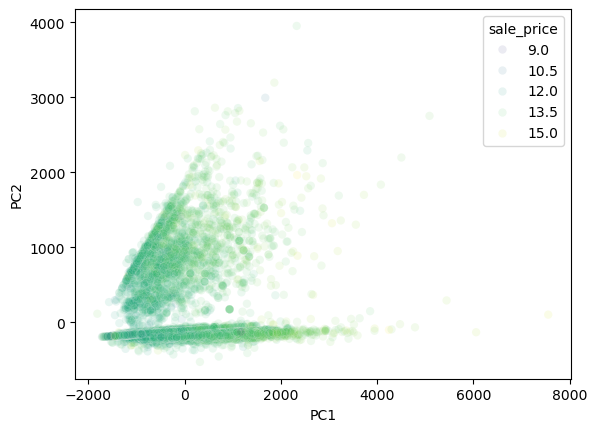

In [5]:
# PCA to 2 dimensions
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(X_house)

sns.scatterplot(x=Z_pca[:, 0], y=Z_pca[:, 1], 
                hue=np.log1p(price), palette='viridis', alpha=0.1)
plt.xlabel("PC1")
plt.ylabel("PC2")

## Example: Heart Attacks
- There are a variety of measurements in the heart attack data that exhibit correlation. How closely are they all related? In particular, how are the measurements correlated?

In [6]:
df_heart = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
df_heart.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [7]:
X_heart = df_heart.loc[:,['anaemia', 'creatinine_phosphokinase', 
                          'ejection_fraction', 'serum_creatinine', 
                          'serum_sodium','DEATH_EVENT'] ]
X_heart.dropna()
X_heart.corr()

,anaemia,creatinine_phosphokinase,ejection_fraction,serum_creatinine,serum_sodium,DEATH_EVENT
anaemia,1.000000,-0.190741,0.031557,0.052174,0.041882,0.066270
creatinine_phosphokinase,-0.190741,1.000000,-0.044080,-0.016408,0.059550,0.062728
ejection_fraction,0.031557,-0.044080,1.000000,-0.011302,0.175902,-0.268603
serum_creatinine,0.052174,-0.016408,-0.011302,1.000000,-0.189095,0.294278
serum_sodium,0.041882,0.059550,0.175902,-0.189095,1.000000,-0.195204
DEATH_EVENT,0.066270,0.062728,-0.268603,0.294278,-0.195204,1.000000


In [8]:
death = X_heart['DEATH_EVENT']
X_heart = X_heart.drop(columns=['DEATH_EVENT'])

# Fit PCA and transform
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(X_heart)

print("Original shape:", X_heart.shape)
print("Reduced shape:", Z_pca.shape)
print("Total variance kept:", pca.explained_variance_ratio_.sum())

Original shape: (299, 5)
Reduced shape: (299, 2)
Total variance kept: 0.9999787707697312


Text(0, 0.5, 'PC2')

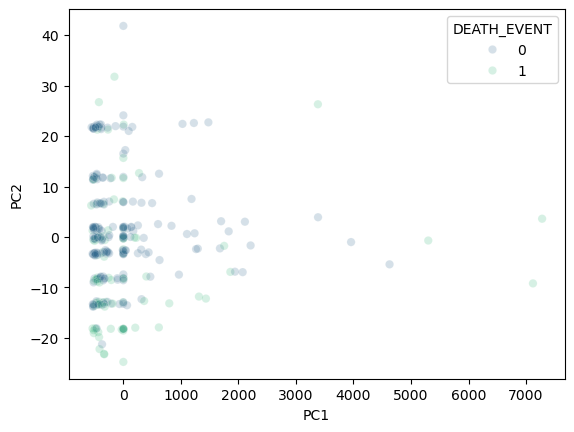

In [9]:
sns.scatterplot(x=Z_pca[:, 0], y=Z_pca[:, 1], 
                hue=death, palette='viridis', alpha=0.2)
plt.xlabel("PC1")
plt.ylabel("PC2")

## Example: Justice Data
- In analyzing sentences and bonds, we might want to include information about a defendant's prior record, but there are many ways to approach that question

In [10]:
df_vcc = pd.read_csv('./data/pretrial_data.csv')
df_vcc.head()

,Unnamed: 0,case_type,age,sex,race,is_poor,bond,bond_type,prior_F,prior_M,gini,released,sentence_type,sentence,bond_NA,held_wo_bail,sentence_NA
0,0,F,31.0,M,W,NaN,NaN,7,0.0,0.0,0.44,NaN,NaN,NaN,True,False,True
1,1,F,60.0,M,B,NaN,NaN,7,13.0,21.0,0.44,0.0,0.0,60.000000,True,False,False
2,2,M,27.0,M,W,NaN,NaN,7,0.0,0.0,0.44,0.0,1.0,12.000000,True,False,False
3,3,M,27.0,M,B,0.0,NaN,7,0.0,9.0,0.44,0.0,1.0,0.985626,True,False,False
4,4,F,28.0,F,W,0.0,NaN,7,0.0,0.0,0.44,1.0,4.0,0.000000,True,False,True


In [11]:
X_vcc = df_vcc.loc[:,['prior_F', 'prior_M','gini','age'] ]
X_vcc = X_vcc.dropna()
X_vcc.corr()

,prior_F,prior_M,gini,age
prior_F,1.000000,0.424809,0.067220,0.198765
prior_M,0.424809,1.000000,0.113327,0.201354
gini,0.067220,0.113327,1.000000,0.030847
age,0.198765,0.201354,0.030847,1.000000


Can we build a one-dimensional "priors" variable that uses information from both `prior_F` and `prior_M`?

In [12]:
# Can we build a single-dimensional "past record index" from the justice data?

from sklearn.decomposition import PCA # Import PCA class
pca = PCA(n_components = 2) # Create PCA instance
pca = pca.fit(X_vcc) # Create the decomposition
Z_vcc = pca.transform(X_vcc) # Project house data; could use new data or test data

print("Original shape:", X_heart.shape)
print("Reduced shape:", Z_pca.shape)
print("Total variance kept:", pca.explained_variance_ratio_.sum())

Original shape: (299, 5)
Reduced shape: (299, 2)
Total variance kept: 0.9550419290612078


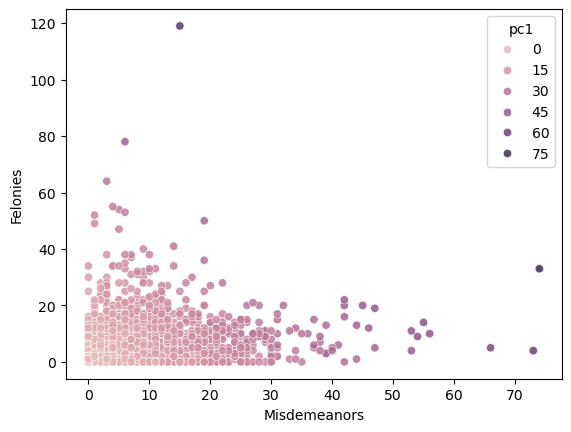

In [13]:
gdf = pd.DataFrame({'Misdemeanors':X_vcc['prior_M'], 
                    'Felonies':X_vcc['prior_F'],
                    'pc1':Z_vcc[:,1]})
sns.scatterplot(data=gdf,x='Misdemeanors', y='Felonies',
                hue='pc1',alpha=.8)
plt.show()

## Data Reduction
- So we are taking many variables that play a similar role, and trying to reduce things down to a more manageable size
- This is really sophisticated, but both (1) widely used and (2) extremely useful
- Let's try to get a sense of the ideas, without feeling like we're drowning in math

# 1. Principal Components Analysis

## Principal Components Analysis
- Imagine we decided we wanted to take an observation of our data, $x_i = (x_{i1}, x_{i2}, ..., x_{iL})$, and approximate it in a lower dimensional space
- Namely, we want to replace $x_i = (x_{i1}, x_{i2}, ..., x_{iL})$ with $\hat{x}_i = (\hat{x}_{i1}, \hat{x}_{i2},...,\hat{x}_{iK})$, with $K<L$; maybe even $K=1$
- For example, we want to take `prior_F` and `prior_M` with $L=2$, and reduce it to one variable, `prior`, with $K=1$
- This is called **dimension reduction**
- Let's do it in a simple, linear way, in the style of $y = a + bx$

## Dimension Reduction
- Let's think about how to make this work. What's our goal here? We want to approximate data for observation $i$, $x_i$, by $\hat{x}_i = a +b_i P$:
$$
\underbrace{[x_{i1}, x_{i2}, ..., x_{iL}]}_{\text{Data}} = [a_{1},...,a_{L}] + \underbrace{[b_{i1}, b_{i2}, ..., b_{iK}]}_{\text{Embedding}} \underbrace{ \left[ \begin{array}{cccc} P_{11} & P_{12} & ... & P_{1L} \\  P_{21} & P_{22} & ... & P_{2L} \\ \vdots & \vdots & \ddots & \vdots \\  P_{K1} & P_{K2} & ... & P_{KL}\end{array}\right]}_{\text{Principal Components, Transposed}} + \underbrace{[r_{i1}, r_{i2}, ..., r_{iL}]}_{\text{Residuals}}
$$
- So we are regressing $x$ on $P$, but learning about $b$ and $P$ at the same time. That's why this is unsupervised learning: The matrix $P$ is something we have to figure out as we go along.

## Residuals and Error [Math]
- Let's rewrite it as 
$$
x_i = a + b_i P +r_i
$$
- Then the residuals are
$$
r_i = x_i - a - b_i P
$$
- And we minimize the sum of squared error across all variables and observations. That is a difficult problem, but not an insurmountable one. Technically, it's
$$
\min_{a,b_i P} \sum_{i=1}^N |x_{i\ell} - a_\ell - b_i \cdot P_{:,\ell} ||^2 \quad \text{ subject to } \quad PP^{\top} = I_K
$$

## Review: Covariance Matrices
- Recall that the sample covariance of $X$ and $Y$ is
$$
s_{xy} = \frac{1}{N} \sum_{i=1}^N (x_i - \bar{x})(y_i - \bar{y}) = s_{xy} 
$$
and 
$$
s_x^2 = \frac{1}{N} \sum_{i=1}^N (x_i - \bar{x})^2 = s_X^2.
$$
- If we write this in a matrix, we get a sample variance-covariance (VCV) matrix, $\hat{S}_X$:
$$
\hat{S}_X = \left[ \begin{array}{cccc} s_1^2 & s_{12} & \dots & s_{1K} \\
s_{21} & s_2^2 & \dots & s_{2K}\\
\vdots & \vdots & \ddots & \vdots \\ s_{K1} & s_{K2} & \dots & s_K^2 \end{array}\right]
$$

## Review: Covariance Matrices
- The core of the solution algorithm is the variance covariance matrix; we essentially want to regress $X$ on itself
- In linear regression, we actually already saw the covariance matrix quite a bit. The slope coefficient was:
$$
\hat{b} = \dfrac{\widehat{\text{cov}}(x,y)}{s_{x}^2}
$$
- In multiple linear regression, what we were actually doing is solving this matrix equation for $\hat{b}$:
$$
\hat{S}_X \hat{b} = \widehat{\text{cov}}(X,y),
$$
which has the solution
$$
\hat{b} = \hat{S}_X^{-1} \widehat{\text{cov}}(X,y), \approx \dfrac{\widehat{\text{cov}}(X,y)}{\hat{S}_X}
$$
- In order to "regress $X$ on itself" to do dimension reduction, $\hat{S}_X$ will play a key role

## (P)Review?: Eigendecomposition
- For a symmetric matrix like $\hat{S}_X$, we want to figure out the "natural way to express it"
- **Eigendecomposition** is about decomposing space into two operations: rotation and stretching
- For the identity matrix with 1's on the diagonal, 
$$
\hat{S} = \left[ \begin{array}{cc} 1 & 0 \\ 0 & 1 \end{array} \right],
$$
there's a coordinate system that stays put when hit by $\hat{S}$: the vectors $e_1 = [1,0]$ and $e_2 = [0,1]$. Then $\hat{S}e_1 = e_1$ and $\hat{S}e_2 = e_2$.
- So $e_1$ and $e_2$ are the natural coordinate system for $\hat{S}$

## (P)Review?: Eigendecomposition
- If the diagonal terms of $S$ weren't 1, they'd rescale $[1,0]$ and $[0,1]$:
$$
S = \left[ \begin{array}{cc} \lambda_1 & 0 \\ 0 & \lambda_2 \end{array} \right],
$$
That **stretching**, though, can be included as a part of our description of $S$: $Se_1 = \lambda_1 e_1$ and $Se_2 = \lambda_2 e_2$
- Those diagonal values $\lambda_\ell$ are called **eigenvalues** of $S$
- We're discovering how $S$ stetches different dimensions of space

## (P)Review?: Eigendecomposition
- What if $\hat{S}$ has off-diagonal values?
- Well, $e_1$ and $e_2$ are going to need to be something else, in order to figure out the solutions to the equation $\hat{S} v = \lambda v$
- A vector $v$ satisfying $\hat{S}v = \lambda v$ is called an **eigenvector** of $\hat{S}$, and when you compute $\hat{S} v$, it just scales $v$ without rotating it
- **Eigenvectors** are the directions that don't get mixed under $\hat{S}$, only stretched
- We're discovering which vectors $\hat{S}_X$ fails to rotate, and which it does move around

## (P)Review?: Eigendecomposition
- For example, take
$$
\hat{S} = 
\left[ \begin{array}{cc} 3 & 1 \\ 1 & 2 \end{array} \right],
$$
- What happens when we multiply $\hat{S}$ times $[1,0]$?
- Are there eigenvalues and eigenvectors for this matrix? `np.linalg.eigh(S)` will find them

In [14]:
import numpy as np

# Example: covariance matrix (symmetric)
S = np.array([
    [2.0, 1.0],
    [1.0, 3.0]
])

# Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(S)  # use eigh for symmetric matrices


In [15]:
print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors (columns):")
print(eigenvectors)

Eigenvalues:
[1.38196601 3.61803399]

Eigenvectors (columns):
[[-0.85065081  0.52573111]
 [ 0.52573111  0.85065081]]


In [16]:
# Check: S v = λ v
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    print(f"\nCheck eigenvector {i}:")
    print("S v =", S @ v)
    print("lambda v =", lam * v)


Check eigenvector 0:
S v = [-1.1755705   0.72654253]
lambda v = [-1.1755705   0.72654253]

Check eigenvector 1:
S v = [1.90211303 3.07768354]
lambda v = [1.90211303 3.07768354]


## (P)Review?: Eigendecomposition
- It turns out, we can write any symmetric 2 $\times$ 2 matrix as
$$
\hat{S}_X = \left[ \begin{array}{cc} v_{11} & v_{21} \\ v_{12} & v_{22} \end{array} \right]
\left[ \begin{array}{cc} \lambda_1 & 0 \\ 0 & \lambda_2 \end{array} \right] \left[ \begin{array}{cc} v_{11} & v_{12} \\ v_{21} & v_{22} \end{array} \right]
$$
where the eigenvalues are on the middle diagonal, and the eigenvectors are stacked horizontally in the last matrix and vertically in the first one
- This is called an **eigendecomposition**

## (P)Review?: Eigendecomposition
- If we sort out the eigenvalues and eigenvectors of a matrix, it turns out that we can write $\hat{S}_X$, we can write
$$
\hat{S}_X = P D P^{\top}
$$
where $D$ **is** a diagonal matrix that stretches and $P$ is the matrix of eigenvectors (why? take linear algebra)
- So all symmetric matrices rotate a vector $x$ by $P^{\top}$, stretch the result by the eigenvalues, and rotation one more time with $P$
- We are tearing apart the matrix and discovering how it rotates and stretches space
- You learn these kinds of concepts in a linear algebra class

## The PCA Algorithm

Here are the solution steps for PCA:

1. **Compute the Covariance Matrix of $X$**: Compute the $K \times K$ covariance matrix of $X$, 
$$ \hat{S}_X = \left[ \begin{array}{cccc} \text{var}(x_1) & \text{cov}(x_1,x_2) & \dots & \text{cov}(x_1,x_K) \\ \text{cov}(x_2,x_1) & \text{var}(x_2) & \dots &  \\ \vdots & \vdots & \ddots & \vdots \\ \text{cov}(x_K,x_1)  & \text{cov}(x_K,x_2) & \dots & \text{var}(x_K) \end{array} \right] $$
2. **Perform a Eigenvector Decomposition of $\text{cov}(X)$**: This transforms $\text{cov}(X) = PDP^{\top}$, where $D$ is a diagonal matrix with elements $(\lambda_1, \lambda_2, ..., \lambda_K)$, called eigenvalues, satisfying $\lambda_1 \ge \lambda_2 \ge ... \ge \lambda_K$, and the columns of $P$ are eigenvectors called **Principal Components**
3. **Transform the Data**: Take the first $L$ eigenvectors/principal components of the decomposition of the covariance matrix, $P_{1:K, 1:L}$, multiply this times the original data centered around its mean:
$$
X_{PCA} = (X-\bar{x}) \cdot P_{1:K,1:L}
$$
This gives an $(N \times K) \times (K \times L) = N \times L$ matrix, reducing the dimension of the data from $K$ to $L$.

In [17]:
## A PCA Decomposition of Housing Variables:

print('Dimensions of initial data: ', X_house.shape, '\n') # Dimension reduction!

# Step 1: Compute covariance matrix
S_house = np.cov(X_house, rowvar=False) # Compute covariance matrix of the data
x_bar = np.mean(X_house, axis=0) # Compute mean of each variable
print(S_house)

Dimensions of initial data:  (16814, 8) 

[[ 5.78237068e+05 -1.07182706e+04  2.74045940e+02  1.23231613e+05
  -6.94364847e+03  3.98459484e+02  4.67449805e+02  2.16274721e+02]
 [-1.07182706e+04  1.04175535e+04  3.27421930e+03 -4.68127456e+03
   1.26660933e+03 -3.54814940e+00 -1.16065170e+01 -9.52036881e+00]
 [ 2.74045940e+02  3.27421930e+03  1.84097489e+05 -2.01996980e+04
   4.73038652e+03  4.15569339e+01  3.50177656e+01 -2.68006783e+01]
 [ 1.23231613e+05 -4.68127456e+03 -2.01996980e+04  8.20559044e+04
  -1.00982293e+04  7.82149515e+01  1.25424661e+02  4.46932957e+01]
 [-6.94364847e+03  1.26660933e+03  4.73038652e+03 -1.00982293e+04
   2.71232806e+04 -9.86904151e+00 -1.05889435e+01 -6.86968603e+00]
 [ 3.98459484e+02 -3.54814940e+00  4.15569339e+01  7.82149515e+01
  -9.86904151e+00  7.94308521e-01  4.20003486e-01  1.92028610e-01]
 [ 4.67449805e+02 -1.16065170e+01  3.50177656e+01  1.25424661e+02
  -1.05889435e+01  4.20003486e-01  6.85511183e-01  2.36880233e-01]
 [ 2.16274721e+02 -9.520368

In [18]:
# Step 2: Eigen decomposition and rank by eigenvalues
eigenvalues, eigenvectors = np.linalg.eig(S_house) # Perform eigenvalue decomposition
eig_val = eigenvalues[ np.argsort(-eigenvalues) ]
eig_vect = eigenvectors[ :, np.argsort(-eigenvalues) ]
eig_val = eig_val/np.sum(eig_val) # Normalize eigenvalues so they sum to 1
print('Sorted Eigenvalues: ', eig_val, '\n')
print('Sorted Eigenvectors: ', eig_vect, '\n')

Sorted Eigenvalues:  [6.88906964e-01 2.12304410e-01 5.95085835e-02 2.79028394e-02
 1.13761086e-02 6.27513690e-07 3.07117581e-07 1.60085543e-07] 

Sorted Eigenvectors:  [[ 9.73034349e-01 -4.50364495e-02 -2.20470650e-01 -4.96478661e-02
  -1.01257306e-02 -9.64439879e-04 -4.38123471e-04 -5.06390508e-05]
 [-1.93523087e-02 -1.95685522e-02 -4.28206661e-02  3.22016989e-02
  -9.98184146e-01 -1.14172180e-04  5.18027247e-04  3.62339891e-04]
 [-1.06218974e-02 -9.88074765e-01  1.52901472e-01  6.44498471e-03
   1.32250455e-02 -2.63704095e-04 -6.77617691e-05  2.43695588e-04]
 [ 2.29057686e-01  1.41345991e-01  9.20777281e-01  2.79826095e-01
  -3.76846694e-02 -1.07761254e-04 -4.27750406e-04  3.37015273e-04]
 [-1.57538378e-02 -3.63075586e-02 -2.79909302e-01  9.58203435e-01
   4.39368274e-02  2.83610118e-04 -8.46396938e-06  1.12041924e-04]
 [ 6.67271735e-04 -2.53814008e-04 -1.25023255e-04 -2.92554036e-04
  -3.31366883e-04  9.15586753e-01 -4.01768187e-01 -1.68077870e-02]
 [ 7.95949003e-04 -1.99279819e-04 

In [19]:
# Step 3: Transform variables by selecting top L eigenvectors
L = 3 # Number of principal components to use
components = eig_vect[:,0:L]
X_pca_ei = (X_house-x_bar) @ components # Multiple original data times the principal component filter, plus the mean

print('Dimensions of final data: ', X_pca_ei.shape) # Dimension reduction!


Dimensions of final data:  (16814, 3)


- So we've gone from 8 to 3 dimensions

## PCA with Sci-Kit
- Of course, sci-kit implements this in a user-friendly way:
    1. Import your PCA class: `from sklearn.decomposition import PCA`
    2. Create a PCA class instance: `pca = PCA(n_components = K)`
    3. Fit the PCA transformer: `pca.fit(X_train)`
    4. Transform new data as desired: `pca.transform(X_new)`
- Math details: The `pca.explained_variance_ratio_` gives the eigenvalues, and the singular values are the square root of the eigenvalues

In [20]:
## Using scikit
from sklearn.decomposition import PCA # Import PCA class
pca = PCA(n_components = 3) # Create PCA instance
pca = pca.fit(X_house) # Create the decomposition
X_pca = pca.transform(X_house) # Project house data; could use new data or test data

In [21]:
print('Their explained variance ratio: ', pca.explained_variance_ratio_)
print('My eigenvalues: ', eig_val[:L], '\n')

Their explained variance ratio:  [0.68890696 0.21230441 0.05950858]
My eigenvalues:  [0.68890696 0.21230441 0.05950858] 



In [22]:
print('Their X_pca: ', X_pca)
print('My X_pca: ', X_pca_ei)

Their X_pca:  [[  309.92462289  -178.37278826    75.6564616 ]
 [  358.50545791  -156.06691117   -63.74438716]
 [ -497.00821177  -135.49287549  -255.08238142]
 ...
 [-1098.34625412   644.78022141   -13.9247026 ]
 [  -66.92746112  -115.58708958  -352.53097152]
 [ -897.89946277  -154.04847124  -164.24891155]]
My X_pca:                   0           1           2
0       309.924623  178.372788   75.656462
1       358.505458  156.066911  -63.744387
2      -497.008212  135.492875 -255.082381
3     -1100.290972  163.415927 -118.390858
4       -71.067834 -190.288330  176.973615
...            ...         ...         ...
16809  1169.906185  124.893408 -206.739557
16810  -485.172794  195.724187  131.307371
16811 -1098.346254 -644.780221  -13.924703
16812   -66.927461  115.587090 -352.530972
16813  -897.899463  154.048471 -164.248912

[16814 rows x 3 columns]


# 2. Picking the Number of Components

## How to Pick the Number of Components
- Since PCA can be understood as a projection/regression, we can define an $R^2$ measure: How much of the variation in the original data is explained by the transformed data?
- This corresponds to summing the eigenvalues/`explained_variance_ratio_`, which equals
$$
R^2 = \dfrac{\lambda_1 + ... + \lambda_L}{\lambda_1 + ... + \lambda_K}
$$
where $K$ is the number of original variables and $L$ is the number of principal components you keep
- What? Why? The eigenvalues are the amount of variation in the data that belong to each eigenvector. That diagonal stretching matrix is measuring the contribution of each principal component to the reconstruction error. 

## How to Pick the Number of Components
- Make a scree plot: How much variation does each component explain? Find the elbow.
- If you cumulatively sum the normalized eigenvalues, you get the total $R^2$ of that number of components: How much total variation is explained by this many components?

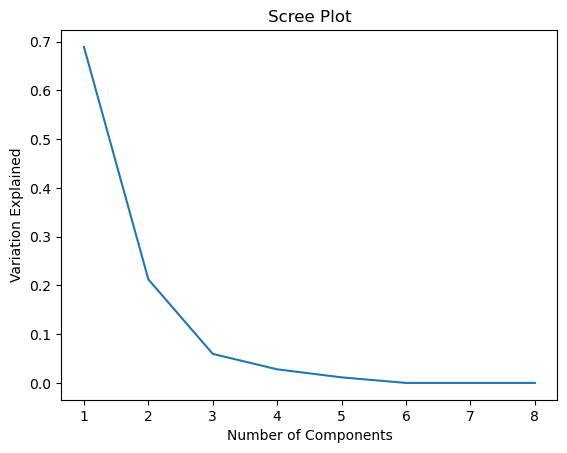

In [23]:
## Model
from sklearn.decomposition import PCA # Import PCA class
pca = PCA(n_components = 8) # Create PCA instance
pca = pca.fit(X_house) # Create the decomposition

# Scree plot:
x = np.linspace(1, X_house.shape[1],X_house.shape[1])
y = pca.explained_variance_ratio_
plt.plot(x,y)
plt.xlabel("Number of Components")
plt.ylabel("Variation Explained")
plt.title('Scree Plot')
plt.show()


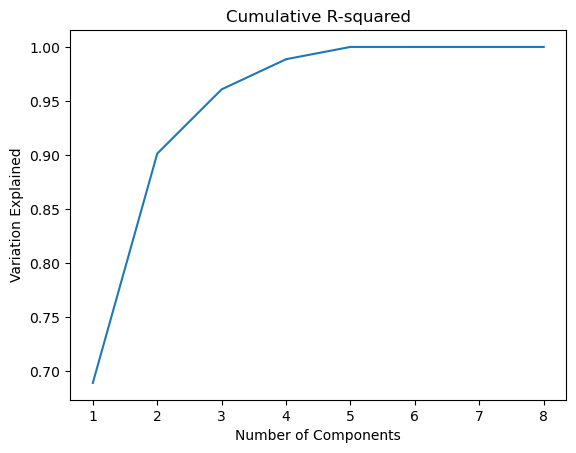

In [24]:
# R^2 plot:
x = np.linspace(1, X_house.shape[1],X_house.shape[1])
y = np.cumsum(pca.explained_variance_ratio_)
plt.plot(x,y)
plt.xlabel("Number of Components")
plt.ylabel("Variation Explained")
plt.title('Cumulative R-squared')
plt.show()

- So you can get an $R^2$ of about .95 with just 3 components of 8

## Application: Indices
- There are a variety of indices published for making comparisons across countries: Human Development Index, V-Dem
- Take your correlated variables on topic $Y$, conduct PCA, extract the first componenet, and call that an "Index of $Y$"
- This is particularly popular in finance, and people try to brand the principal components: "Volatility", "Liquidity", etc.
- I am deeply skeptical of this kind of work. To me, PCA is a computational step to get traction on handling high dimensional data, and not an end in itself. Interpreting the eigenvalues and components can often drift closer to astrology than science.

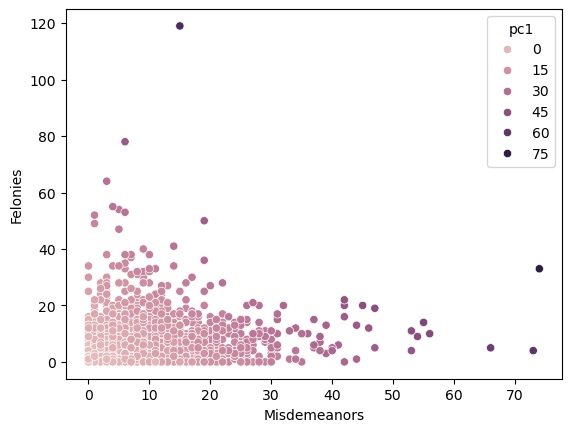

In [25]:
# Can we build a single-dimensional "past record index" from the justice data?

from sklearn.decomposition import PCA # Import PCA class
pca = PCA(n_components = 2) # Create PCA instance
pca = pca.fit(X_vcc) # Create the decomposition
Z_vcc = pca.transform(X_vcc) # Project house data; could use new data or test data

gdf = pd.DataFrame({'Misdemeanors':X_vcc['prior_M'], 
                    'Felonies':X_vcc['prior_F'],
                    'pc1':Z_vcc[:,1]})
sns.scatterplot(data=gdf,x='Misdemeanors', y='Felonies',hue='pc1')
plt.show()


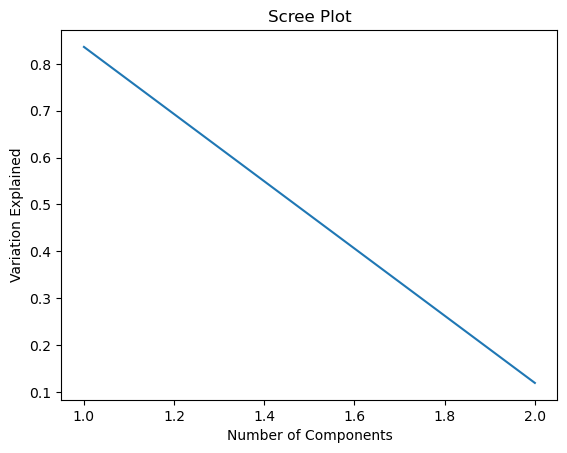

In [26]:
# Scree plot:
x = np.linspace(1, Z_vcc.shape[1],Z_vcc.shape[1])
y = pca.explained_variance_ratio_
plt.plot(x,y)
plt.xlabel("Number of Components")
plt.ylabel("Variation Explained")
plt.title('Scree Plot')
plt.show()

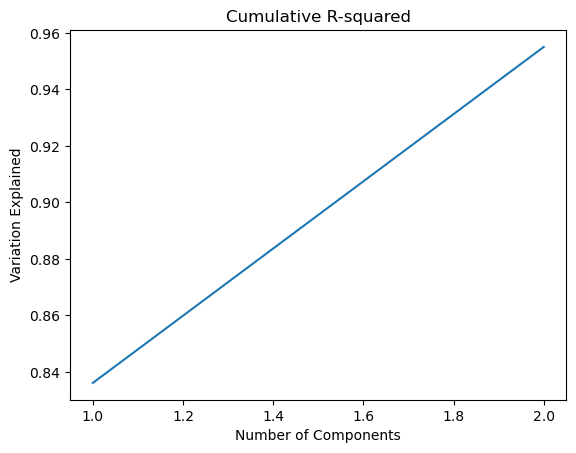

In [27]:
# R^2 plot:
x = np.linspace(1, Z_vcc.shape[1],Z_vcc.shape[1])
y = np.cumsum(pca.explained_variance_ratio_)
plt.plot(x,y)
plt.xlabel("Number of Components")
plt.ylabel("Variation Explained")
plt.title('Cumulative R-squared')
plt.show()

# So the one dimensional index gets 83% of the variation of the two variables together

## Application: Indices
- So, in many situations, you have a variety of correlated measures of the same phenomenon, like "Past Record"
- Here, the first principal component seems to track mostly the felonies; that might be fine
- You can use the first Principal Component to proxy for the basket of variables, rather than try to use them all
- The first principal component explains about 73% of the variation in outcomes, so it's not bad, but in high stakes settings, 73% might not be enough --- I certainly wouldn't want to recommend holding someone without bond on the basis of 73%

## Application: Clustering and Dimension Reduction
- When clustering, we often do PCA on the clustering variables to orthogonalize them and improve performance
- So you first maxmin normalize, then apply PCA, and finally conduct the $K$-means algorithm (or another) on the transformed data
- This also aids visualization: You can plot the first two principal components against the final cluster assignment to visualize your results, even when the data are high-dimensional

Text(0.5, 1.0, 'PCA of Housing Data')

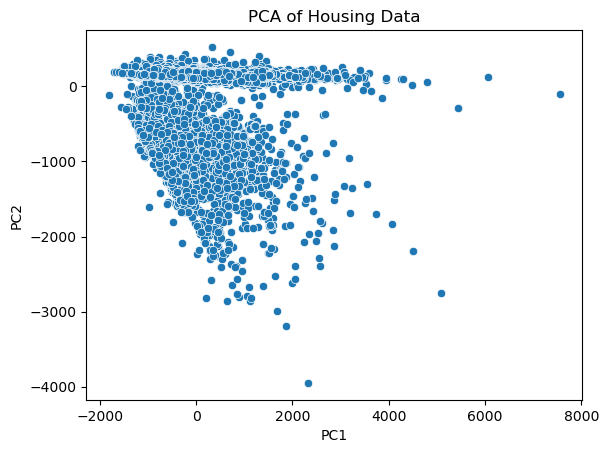

In [28]:
sns.scatterplot(x=X_pca_ei.iloc[:,0],y=X_pca_ei.iloc[:,1])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Housing Data')

In [29]:
## Maxmin normalize:
def maxmin(x): # Max-min scaler function
    x = (x-min(x))/(max(x)-min(x))
    return x
Z_mm = X_pca_ei.apply(maxmin) # Normalize the data

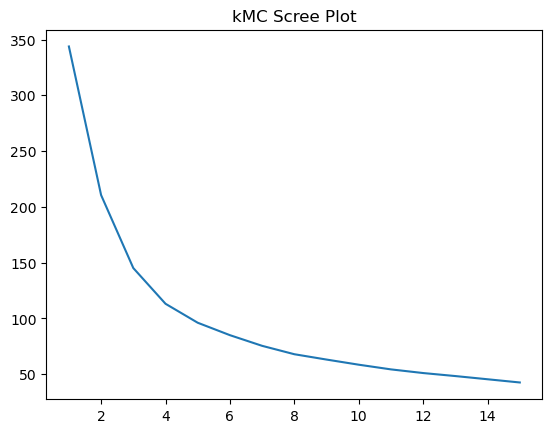

In [30]:
## Implement Clustering:
from sklearn.cluster import KMeans 
k_bar = 15
SSE = np.zeros(k_bar) 
for k in range(k_bar): # For indices from 0 to k_bar-1
    model = KMeans(n_clusters=k+1, max_iter=300, n_init = 10, random_state=0) # Create a model for k
    model = model.fit(Z_mm) # Fit the emodel
    SSE[k] = model.inertia_ # Record the sum of squared error for k in the SSE vector
scree_plot = sns.lineplot(x=np.linspace(1,k_bar,k_bar), y=SSE).set_title('kMC Scree Plot') # Create scree plot

# Four looks good?

<Axes: xlabel='pc1', ylabel='pc2'>

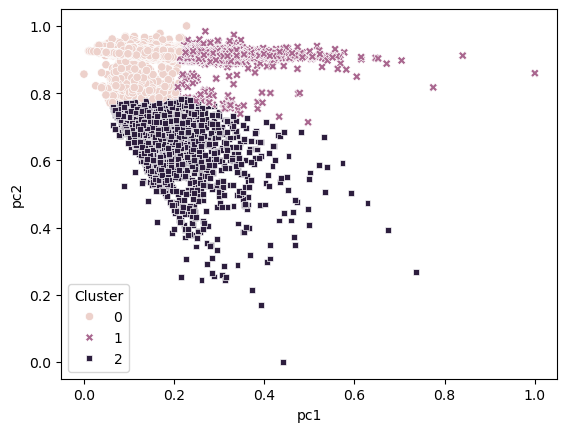

In [31]:
model = KMeans(n_clusters=3, n_init=10, random_state=1)
model = model.fit(Z_mm)
cluster_hat = model.predict(Z_mm)

gdf = pd.DataFrame({'pc1':Z_mm.iloc[:,0], 
                    'pc2':Z_mm.iloc[:,1],
                    'Cluster':cluster_hat})
sns.scatterplot(data=gdf,x='pc1', y='pc2',hue='Cluster',style='Cluster')

- OK, I just want to do it with my weapon of choice, the Gaussian Mixture Model...

<Axes: xlabel='pc1', ylabel='pc2'>

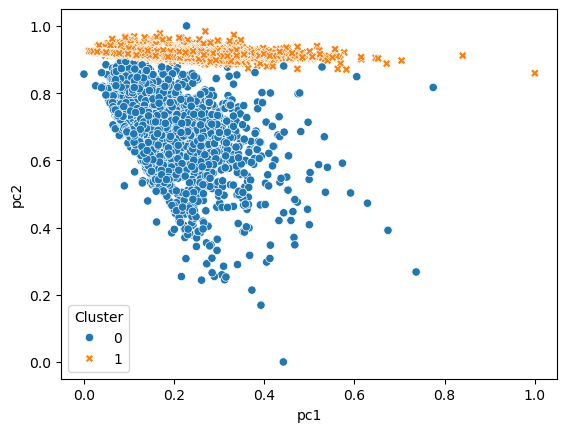

In [32]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(
    n_components=2, 
    covariance_type="full",
    random_state=100
)
gmm.fit(Z_mm)
cluster_hat = gmm.predict(Z_mm)
gdf = pd.DataFrame({'pc1':Z_mm.iloc[:,0], 
                    'pc2':Z_mm.iloc[:,1],
                    'Cluster':cluster_hat})
sns.scatterplot(data=gdf,x='pc1', y='pc2',hue='Cluster',style='Cluster')

## Application: Clustering and Dimension Reduction
- So we use PCA to decorrelate the variables, and then use just the first two principal components to make the scatter plot
- This kind of trick works really well in high dimensional situations, where we want to use all the data but our ability to conceptualize what's happening in more than two/three dimensions is very limited
- We are still omitting some of the principal components, which didn't span the original data set --- we are losing something, for sure. You could use the PCA scree plot of $R^2$ to assess the loss.
- What do the principal components mean? What do the clusters mean? No clue! It's just a computational/statistical step, unless we want to dig into the results and psycho-analyze what they mean.

## Application: Principal Components Regression
- Rather than LASSO or fuss around to do feature selection, why not transform the data with PCA, then chose which $L$ of $K$ transformed variables to include as features/covariates?
- This is very clever: For $K$ features/covariates, there are $2^K$ possible choices of subsets of variables, while with PCA, there are only $K$ ways to choose the first $L$ principal components
- Problem: Explainability/Interpretability suffers, because we can't really make sense of what the transformed variables really mean. They're just a technology to make predictions, and rely on the dimensions we dropped. You can use this for prediction-making, but interpreting indices and including them as covariates is not typically a responsible thing to do.

In [33]:
# Linear regression with first pca
df_heart['age_sq'] = df_heart['age']**2
ctrl = ['age', 'age_sq', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']
X = df_heart.loc[:,ctrl]
y = df_heart['DEATH_EVENT']
X.head()

,age,age_sq,diabetes,high_blood_pressure,sex,smoking
0,75.0,5625.0,0,1,1,0
1,55.0,3025.0,0,0,1,0
2,65.0,4225.0,0,0,1,1
3,50.0,2500.0,0,0,1,0
4,65.0,4225.0,1,0,0,0


In [34]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X,y)
print(reg.intercept_) # Intercept value
print(reg.coef_) # Regression coefficients
print(reg.score(X, y)) # R squared measure

0.8936656326917289
[-0.02952002  0.0003114   0.03318989  0.0608468  -0.01528099  0.00490473]
0.08225569420285128


In [35]:
## Implement PCA:
from sklearn.decomposition import PCA 
pca = PCA(n_components = 5) 
pca = pca.fit(X_heart) 
Z_heart = pca.transform(X_heart) 

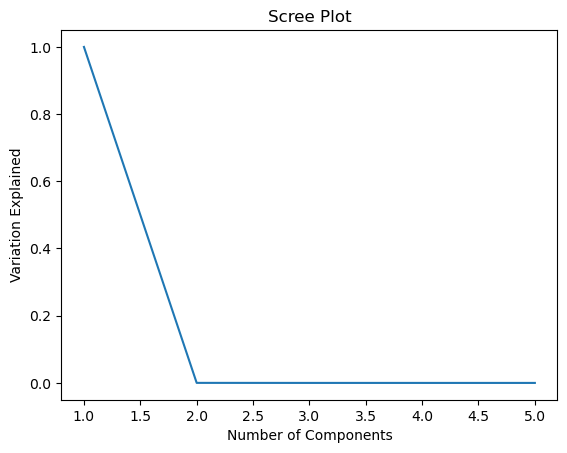

In [36]:
# Scree plot:
x = np.linspace(1, X_heart.shape[1],X_heart.shape[1])
y = pca.explained_variance_ratio_
plt.plot(x,y)
plt.xlabel("Number of Components")
plt.ylabel("Variation Explained")
plt.title('Scree Plot')
plt.show()

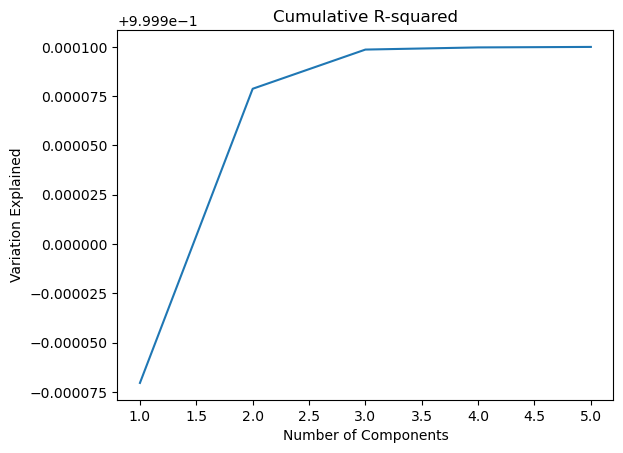

[6.88906964e-01 2.12304410e-01 5.95085835e-02 2.79028394e-02
 1.13761086e-02 6.27513690e-07 3.07117581e-07 1.60085543e-07]


In [37]:
# R^2 plot:
x = np.linspace(1, X_heart.shape[1],X_heart.shape[1])
y = np.cumsum(pca.explained_variance_ratio_)
plt.plot(x,y)
plt.xlabel("Number of Components")
plt.ylabel("Variation Explained")
plt.title('Cumulative R-squared')
plt.show()
print(eig_val)

In [38]:
reg = LinearRegression()
reg.fit(Z_heart[:,:3],df_heart['DEATH_EVENT'])
print(reg.intercept_) # Intercept value
print(reg.coef_) # Regression coefficients
print(reg.score(Z_heart[:,:3], df_heart['DEATH_EVENT'])) # R squared measure

0.3210702341137123
[ 3.02351468e-05 -1.06663999e-02 -1.61626105e-02]
0.09938949530015606


## Application: Image and Sound Processing
- Images are typically very high dimensional data: Imagine a black-and-white image is encoded as $R \times C$ pixel values of grey coded from white to black. For a high resolution photo, that will be extremely high dimensional (and for color we would have to track four such matrices, corresponding to cyan/magenta/yellow/black)
- PCA provides a way of "strategically throwing away" data to compress images and sound by filtering by the first $K$ components

## Application: Natural Language Processing
- PCA is used extensively in the natural language processing literature as something called word2vec
- How do you turn words into vectors?

    0. **Tokenize** your text by breaking it into words or n-grams
    1. One-hot encode your sentences. A row is a sentence and a column is a token, and a value answers the question, "Does this sentence include this token?"
    2. Take the transpose. Now, a row is a token and a column is a sentence, and a value answers the question, "Does this token appear in this sentence?"
    3. Conduct PCA to get a **vector embedding** of words into a lower dimensional feature space

- This is the core tool of modern NLP to convert text into a format that we can analyze; notice, it's the same thing as image processing

## Application: Recommender Systems and Matrix Completion
- Think about the kind of data that Netflix has: Millions of users, and their ratings for movies
- Imagine each row is a user and each column is a movie. Then a value is a rating for a movie
- Netflix's problem is missing values: They don't know how you'll respond to a movie you've never seen
- Netflix (and other companies) use PCA-type methods to infer how people decide to rate movies, and impute values. Then they make recommendations on the basis of the imputation.

## Conclusion
- PCA is a very valuable tool to have available for dimensionality reduction of complex data, and appears everywhere "under the hood" to handle problems when you have "too many variables"
- Whenever you're in a situation where you have baskets of variables that are all similar, you can de-correlate them and scale the complexity of the resulting set up and down to taste
- This is primarily a computational tool that conducts an intermediate step to process data, and interpreting the results is kind of fool-hardy unless you really know what you're doing. Personally, I am very skeptical of results for which the PCA is itself the final result (similar to clustering)
- Any good idea, of course, has a huge number of extensions and imitations: This is the entry level version of a set of big ideas that you can explore and adapt to your specific problems